# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

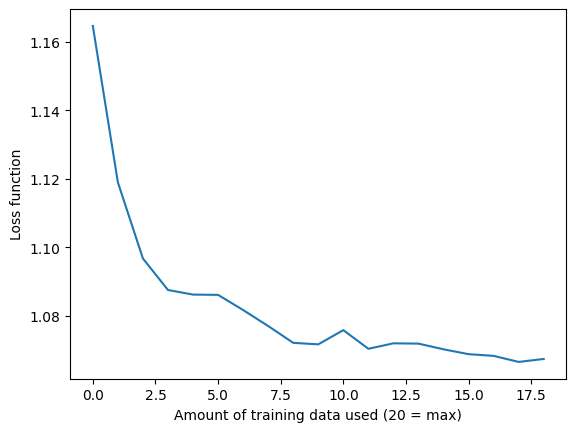

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

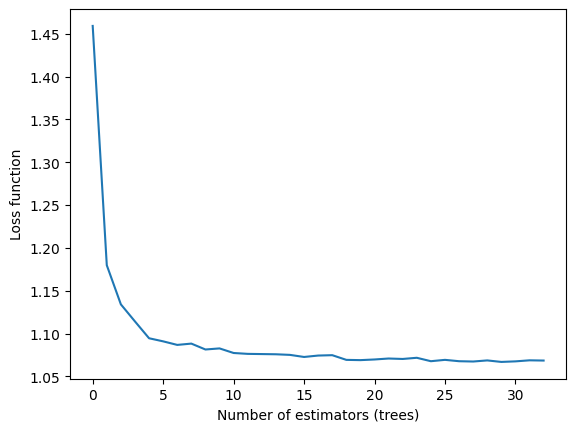

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

## The "Amount of training data used" graph is more important, as it speaks to the heart of model learning and generalization. It’s especially valuable when working with healthcare datasets, where data scarcity and quality are major concerns.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

### Diabetic Nephropathy

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load your dataset (assuming it's in a DataFrame called df)
df = pd.read_csv("Diabetic_Nephropathy.csv")  # Replace with actual path or use df = ...

# Encode categorical variables
label_encoders = {}
for col in ['Sex', 'Smoking', 'Drinking', 'Insulin', 'Metformin', 'Lipid lowering drugs']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df.drop(columns=['Diabetic nephropathy (DN)'])  # Predicting DN
y = df['Diabetic nephropathy (DN)']


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Perform 5-fold cross-validation using accuracy
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Cross-validated accuracy scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")


Cross-validated accuracy scores: [0.81168831 0.76623377 0.73856209 0.75163399 0.73856209]
Mean accuracy: 0.7613


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validated accuracy: 0.7652


In [5]:
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7208
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       111
           1       0.50      0.14      0.22        43

    accuracy                           0.72       154
   macro avg       0.62      0.54      0.52       154
weighted avg       0.67      0.72      0.66       154



In [4]:
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7208
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       111
           1       0.50      0.14      0.22        43

    accuracy                           0.72       154
   macro avg       0.62      0.54      0.52       154
weighted avg       0.67      0.72      0.66       154



### CKD Risk Factors

In [56]:
df = pd.read_csv("(CKD)-Risk_Factors.csv")

# Helper to convert ranges and symbolic values to numeric
def parse_value(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if '-' in val:
        parts = val.split('-')
        return (float(parts[0]) + float(parts[1])) / 2
    elif '<' in val:
        return float(val.replace('<', '').strip()) * 0.9
    elif '≥' in val:
        return float(val.replace('≥', '').strip())
    elif val.isnumeric():
        return float(val)
    else:
        try:
            return float(val)
        except:
            return np.nan

# Apply parsing to range-based columns
range_cols = ['sg', 'bgr', 'bu', 'sod', 'sc', 'pot', 'hemo', 'pcv', 'rbcc', 'wbcc', 'grf', 'age', 'al', 'su']
for col in range_cols:
    df[col] = df[col].apply(parse_value)

# Encode categorical columns
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class', 'stage']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Define features and target
X = df.drop(columns=['affected', 'class'])
y = df['affected']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


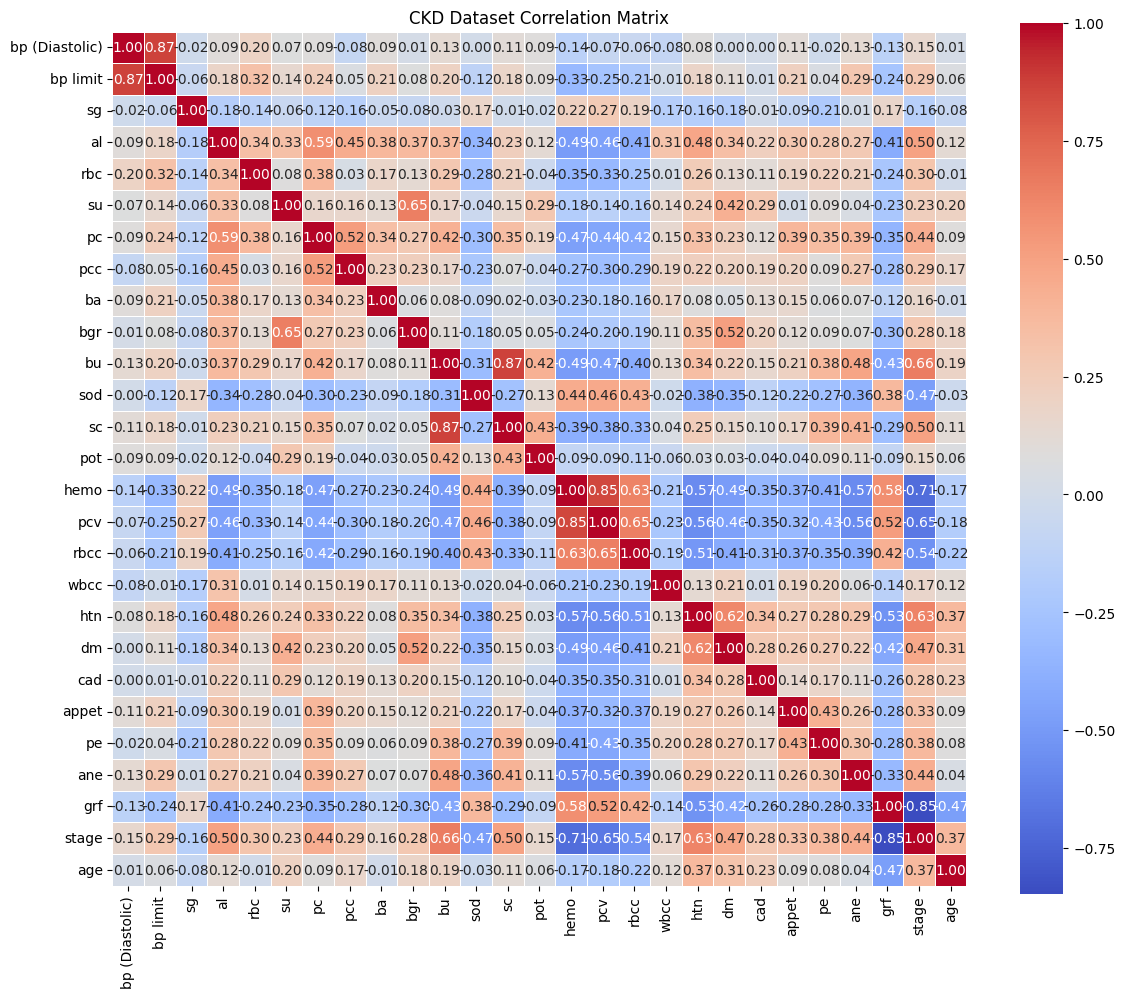

In [57]:
corr_matrix = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('CKD Dataset Correlation Matrix')
plt.tight_layout()
plt.show()

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print(f"Cross-validated accuracy scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")


Cross-validated accuracy scores: [0.9 1.  1.  1.  1. ]
Mean accuracy: 0.9800


In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_scaled, y)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated accuracy: 0.9850


In [61]:
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Train best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9625
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        30
           1       0.94      1.00      0.97        50

    accuracy                           0.96        80
   macro avg       0.97      0.95      0.96        80
weighted avg       0.96      0.96      0.96        80



### AKI Mimic

In [11]:
from sklearn.preprocessing import StandardScaler

# Load your AKI dataset
df = pd.read_csv("(AKI)-MIMIC_Subset.csv")  # Replace with actual path or use df = ...

# Drop rows with missing target
df.dropna(subset=['aki_stage'], inplace=True)

# Encode categorical features
categorical_cols = ['gender', 'race', 'unit']
df[categorical_cols] = df[categorical_cols].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

# Fill missing values in numeric columns with median
numeric_cols = df.select_dtypes(include='number').columns.drop('aki_stage')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Define features and target
X = df.drop(columns=['aki_stage'])
y = df['aki_stage']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')

print(f"Cross-validated accuracy scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")


Cross-validated accuracy scores: [0.58801498 0.63       0.59       0.58       0.58625   ]
Mean accuracy: 0.5949


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_scaled, y)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validated accuracy: 0.6066


In [14]:
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.5730
Classification Report:
              precision    recall  f1-score   support

           1       0.48      0.08      0.14       180
           2       0.54      0.83      0.66       380
           3       0.69      0.53      0.60       241

    accuracy                           0.57       801
   macro avg       0.57      0.48      0.47       801
weighted avg       0.57      0.57      0.52       801



# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

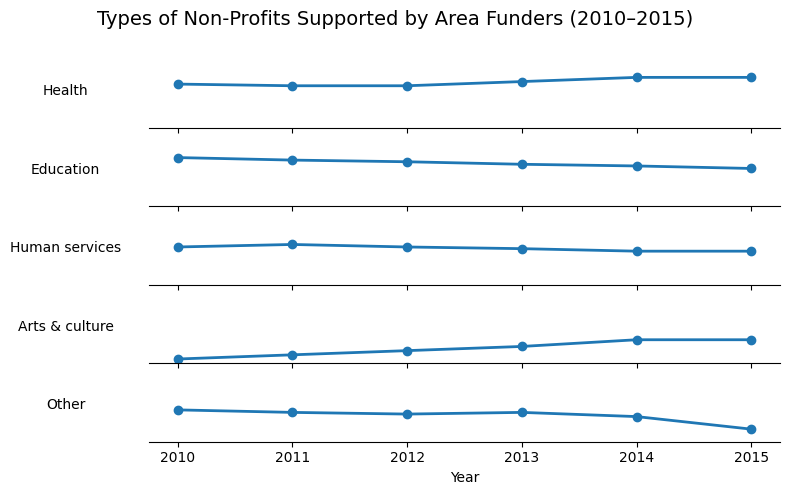

In [19]:
import matplotlib.pyplot as plt

# Data setup
years = [2010, 2011, 2012, 2013, 2014, 2015]
data = {
    "Health":        [67, 65, 65, 70, 75, 75],
    "Education":     [73, 70, 68, 65, 63, 60],
    "Human services":[60, 63, 60, 58, 55, 55],
    "Arts & culture":[20, 25, 30, 35, 43, 43],
    "Other":         [53, 50, 48, 50, 45, 30]
}

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 5), sharex=True)

# Plot each category in its own subplot
for ax, (category, values) in zip(axes, data.items()):
    ax.plot(years, values, marker='o', linewidth=2, color='tab:blue')
    ax.set_ylabel(category, rotation=0, labelpad=60, fontsize=10)
    ax.set_ylim(15, 85)
    ax.set_yticks([])
    
    # Remove all spines (borders)
    for spine_name, spine in ax.spines.items():
        spine.set_visible(spine_name == 'bottom')

# Final formatting
axes[-1].set_xlabel("Year")
plt.suptitle("Types of Non-Profits Supported by Area Funders (2010–2015)", fontsize=14)
plt.xticks(years)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
